# deFBA — Dynamic Enzyme-cost Flux Balance Analysis

Proof-of-concept implementation of the small-scale *E. coli* metabolic-genetic network from
Jabarivelisdeh (2021, Ch. 3), extended with a neural-network surrogate and bilevel optimisation.

**Units throughout:** fluxes in mmol/gDW/h · concentrations in mM · enzyme pools in µmol/gDW · time in h

In [1]:
import sys, os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parents[0]
np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings('ignore', category=UserWarning)
print('Imports OK')

Imports OK


---
## Section 1 — Model Specification

All parameters hard-coded from Jabarivelisdeh (2021) Tables 3.2 and 3.3.

### 1.1 Metabolite index

In [2]:
# Intracellular (quasi-steady-state) metabolites — tracked in S_x
INT_METS = [
    'ATP',       # 0
    'ADP',       # 1
    'NADH',      # 2
    'NAD',       # 3
    'PEP',       # 4
    'PYR',       # 5
    'G6P',       # 6
    'GLC_in',    # 7
    'T3P',       # 8
    'AcCoA',     # 9
    'CoA',       # 10
    'OAA',       # 11
    'AKG',       # 12
    'AA',        # 13
]
N_INT = len(INT_METS)

# Extracellular (slow) metabolites — tracked in S_y
EXT_METS = [
    'GLC',       # 0
    'LCT',       # 1
    'O2',        # 2
    'ACT',       # 3
    'ETH',       # 4
    'BM',        # 5
]
N_EXT = len(EXT_METS)

print(f'Intracellular metabolites : {N_INT}')
print(f'Extracellular metabolites : {N_EXT}')

Intracellular metabolites : 14
Extracellular metabolites : 6


### 1.2 Reaction list (Table 3.2)

In [3]:
i = {m: idx for idx, m in enumerate(INT_METS)}

# Extracellular metabolite indices (matches your EXT_METS list)
GLC, LCT, O2, ACT, ETH, BM = 0, 1, 2, 3, 4, 5

# kcat values are given in min⁻¹ in Table 3.2; converted to h⁻¹ (* 60) on entry.
# The global scaling factor f (0.65 anaerobic / 0.60 aerobic) is applied
# inside solve_deFBA_LP, not pre-multiplied here.
# FOR (formate) is intentionally not tracked — see modelling note for reaction 8.

REACTIONS = [
    # 1 — Phosphotransferase system (glucose uptake + phosphorylation)
    # GLC + PEP → G6P + PYR
    dict(idx=0,  name='pts',  gene='pts',  enzyme='E_pts',
         kcat=8750*60, reversible=False,
         stoich_int={i['PEP']: -1, i['G6P']: +1, i['PYR']: +1},
         stoich_ext={GLC: -1}),

    # 2 — Lactose permease (transport only, produces intracellular glucose)
    # LCT → GLC_in
    dict(idx=1,  name='lacY', gene='lacY', enzyme='E_lacY',
         kcat=1908*60, reversible=False,
         stoich_int={i['GLC_in']: +1},
         stoich_ext={LCT: -1}),

    # 3 — Glucokinase (phosphorylates internal glucose)
    # GLC_in + ATP → G6P + ADP
    dict(idx=2,  name='glk',  gene='glk',  enzyme='E_glk',
         kcat=1533*60, reversible=False,
         stoich_int={i['GLC_in']: -1, i['ATP']: -1, i['G6P']: +1, i['ADP']: +1},
         stoich_ext={}),

    # 4 — Upper glycolysis to T3P (named tpi in the dissertation; lumped split)
    # G6P + ATP → 2 T3P + ADP
    dict(idx=3,  name='tpi',  gene='tpi',  enzyme='E_tpi',
         kcat=2133*60, reversible=False,
         stoich_int={i['G6P']: -1, i['ATP']: -1, i['T3P']: +2, i['ADP']: +1},
         stoich_ext={}),

    # 5 — Pentose phosphate pathway (lumped oxidative branch)
    # G6P + 6 NAD⁺ → T3P + 6 NADH
    dict(idx=4,  name='pgl',  gene='pgl',  enzyme='E_pgl',
         kcat=1585*60, reversible=False,
         stoich_int={i['G6P']: -1, i['NAD']: -6, i['T3P']: +1, i['NADH']: +6},
         stoich_ext={}),

    # 6 — Lower glycolysis (named pgk in the dissertation; lumped GAPDH→PEP)
    # T3P + NAD⁺ + ADP → PEP + NADH + ATP
    dict(idx=5,  name='pgk',  gene='pgk',  enzyme='E_pgk',
         kcat=1740*60, reversible=False,
         stoich_int={i['T3P']: -1, i['NAD']: -1, i['ADP']: -1,
                     i['PEP']: +1, i['NADH']: +1, i['ATP']: +1},
         stoich_ext={}),

    # 7 — Pyruvate kinase
    # PEP + ADP → PYR + ATP
    dict(idx=6,  name='pyk',  gene='pyk',  enzyme='E_pyk',
         kcat=5762*60, reversible=False,
         stoich_int={i['PEP']: -1, i['ADP']: -1, i['PYR']: +1, i['ATP']: +1},
         stoich_ext={}),

    # 8 — Pyruvate-formate lyase (anaerobic AcCoA production)
    # PYR + CoA → AcCoA + FOR
    # NOTE: FOR not tracked in S_x — implicit dead-end sink (see modelling note)
    dict(idx=7,  name='pfl',  gene='pfl',  enzyme='E_pfl',
         kcat=5676*60, reversible=False,
         stoich_int={i['PYR']: -1, i['CoA']: -1, i['AcCoA']: +1},
         stoich_ext={}),

    # 9 — Pyruvate dehydrogenase (aerobic AcCoA production)
    # PYR + CoA + NAD⁺ → AcCoA + NADH
    dict(idx=8,  name='pdh',  gene='pdh',  enzyme='E_pdh',
         kcat=59728*60, reversible=False,
         stoich_int={i['PYR']: -1, i['CoA']: -1, i['NAD']: -1,
                     i['AcCoA']: +1, i['NADH']: +1},
         stoich_ext={}),

    # 10 — PEP carboxylase (anaplerotic, replenishes OAA)
    # PEP → OAA
    dict(idx=9,  name='ppc',  gene='ppc',  enzyme='E_ppc',
         kcat=9518*60, reversible=False,
         stoich_int={i['PEP']: -1, i['OAA']: +1},
         stoich_ext={}),

    # 11 — Isocitrate dehydrogenase (lumped first half of TCA)
    # OAA + AcCoA + NAD⁺ → AKG + CoA + NADH
    dict(idx=10, name='icd',  gene='icd',  enzyme='E_icd',
         kcat=3171*60, reversible=False,
         stoich_int={i['OAA']: -1, i['AcCoA']: -1, i['NAD']: -1,
                     i['AKG']: +1, i['CoA']: +1, i['NADH']: +1},
         stoich_ext={}),

    # 12 — Malate dehydrogenase (lumped second half of TCA)
    # AKG + 2 NAD⁺ + ADP → OAA + 2 NADH + ATP
    dict(idx=11, name='mdh',  gene='mdh',  enzyme='E_mdh',
         kcat=2444*60, reversible=False,
         stoich_int={i['AKG']: -1, i['NAD']: -2, i['ADP']: -1,
                     i['OAA']: +1, i['NADH']: +2, i['ATP']: +1},
         stoich_ext={}),

    # 13 — Acetate kinase  *** REGULATED in Strategy 1b ***
    # AcCoA + ADP → ATP + CoA + ACT
    dict(idx=12, name='ackA', gene='ackA', enzyme='E_ackA',
         kcat=1809*60, reversible=False,
         stoich_int={i['AcCoA']: -1, i['ADP']: -1,
                     i['ATP']: +1, i['CoA']: +1},
         stoich_ext={ACT: +1}),

    # 14 — Ethanol synthesis (adhE, bifunctional)
    # AcCoA + 2 NADH → ETH + CoA + 2 NAD⁺
    dict(idx=13, name='adhE', gene='adhE', enzyme='E_adhE',
         kcat=52329*60, reversible=False,
         stoich_int={i['AcCoA']: -1, i['NADH']: -2,
                     i['CoA']: +1, i['NAD']: +2},
         stoich_ext={ETH: +1}),

    # 15 — Glutamate dehydrogenase (amino acid synthesis from AKG)
    # 4 AKG + 4 NADH + 8 ATP → 5 AA + 4 NAD⁺ + 8 ADP
    dict(idx=14, name='gdhA', gene='gdhA', enzyme='E_gdhA',
         kcat=7560*60, reversible=False,
         stoich_int={i['AKG']: -4, i['NADH']: -4, i['ATP']: -8,
                     i['AA']: +5, i['NAD']: +4, i['ADP']: +8},
         stoich_ext={}),

    # 16 — NADH dehydrogenase / respiration (aerobic only — O₂ required)
    # 2 NADH + O₂ + 2.5 ADP → 2 NAD⁺ + 2.5 ATP
    dict(idx=15, name='nuo',  gene='nuo',  enzyme='E_nuo',
         kcat=1935*60, reversible=False,
         stoich_int={i['NADH']: -2, i['ADP']: -2.5,
                     i['NAD']: +2, i['ATP']: +2.5},
         stoich_ext={O2: -1}),
]

N_RXN     = len(REACTIONS)
RXN_NAMES = [r['name'] for r in REACTIONS]
print(f'Metabolic reactions: {N_RXN}')
print('Reactions:', RXN_NAMES)

Metabolic reactions: 16
Reactions: ['pts', 'lacY', 'glk', 'tpi', 'pgl', 'pgk', 'pyk', 'pfl', 'pdh', 'ppc', 'icd', 'mdh', 'ackA', 'adhE', 'gdhA', 'nuo']


### 1.3 Enzyme pool definitions (Table 3.3)

In [4]:
B0 = 0.005 # gDW/L

# Each entry corresponds to one component of the enzyme pool vector P.
#   b       : molecular weight (g/mol)
#   kcat_r  : ribosome kcat for synthesis (s⁻¹, converted to h⁻¹ * 60)
#   kdeg    : first-order degradation rate (h⁻¹)
#   P0      : initial pool (µmol/gDW), from RBA in Table 3.3

ENZYMES = [
    dict(name='E_pts',  b=257022,  kcat_r=0.31, kdeg=0.014, P0=0.00011/B0),
    dict(name='E_lacY', b=255714,  kcat_r=0.31, kdeg=0.014, P0=0.00014/B0),
    dict(name='E_glk',  b=34989,   kcat_r=2.24, kdeg=0.014, P0=0.00017/B0),
    dict(name='E_tpi',  b=247648,  kcat_r=0.32, kdeg=0.014, P0=0.000087/B0),
    dict(name='E_pgl',  b=251136,  kcat_r=0.31, kdeg=0.014, P0=0.0006/B0),
    dict(name='E_pgk',  b=193475,  kcat_r=0.41, kdeg=0.014, P0=0.00075/B0),
    dict(name='E_pyk',  b=204920,  kcat_r=0.38, kdeg=0.014, P0=0.0),
    dict(name='E_pfl',  b=192494,  kcat_r=0.41, kdeg=0.014, P0=0.00017/B0),
    dict(name='E_pdh',  b=4588464, kcat_r=0.02, kdeg=0.014, P0=0.0),
    dict(name='E_ppc',  b=384988,  kcat_r=0.20, kdeg=0.014, P0=0.000038/B0),
    dict(name='E_icd',  b=319152,  kcat_r=0.25, kdeg=0.014, P0=0.00011/B0),
    dict(name='E_mdh',  b=456274,  kcat_r=0.17, kdeg=0.014, P0=0.0),
    dict(name='E_ackA', b=122516,  kcat_r=0.64, kdeg=0.014, P0=0.00032/B0),
    dict(name='E_adhE', b=3884760, kcat_r=0.02, kdeg=0.014, P0=0.0),
    dict(name='E_gdhA', b=639394,  kcat_r=0.12, kdeg=0.014, P0=0.000012/B0),
    dict(name='E_nuo',  b=195655,  kcat_r=0.40, kdeg=0.014, P0=0.00146/B0),
    dict(name='R',      b=2289611, kcat_r=0.10, kdeg=0.007, P0=0.00063/B0),
    dict(name='Q',      b=54980,   kcat_r=1.55, kdeg=0.007, P0=0.05/B0),
]


N_ENZ     = len(ENZYMES)
ENZ_NAMES = [e['name'] for e in ENZYMES]
IDX_R     = ENZ_NAMES.index('R')
IDX_Q     = ENZ_NAMES.index('Q')

# Parameter arrays
b_vec    = np.array([e['b']      for e in ENZYMES])              # g/mol
kcat_r   = np.array([e['kcat_r'] for e in ENZYMES]) * 60       # min⁻¹ -> h⁻¹
P0_vec   = np.array([e['P0']     for e in ENZYMES])              # µmol/gDW
kdeg_vec = np.array([e['kdeg']   for e in ENZYMES]) 

# kcat for metabolic reactions (already in h⁻¹)
kcat_met = np.array([r['kcat'] for r in REACTIONS])

# Map metabolic reaction → enzyme index in P
rxn_to_enz = np.array([
    ENZ_NAMES.index(r['enzyme']) if r['enzyme'] in ENZ_NAMES else -1
    for r in REACTIONS
])

print(f'Enzyme components (incl. R, Q): {N_ENZ}')
print(f'b^T P0 = {b_vec @ P0_vec * 1e-6:.4f} g/gDW  (sanity: should be ~1)')
print(f'Ribosome idx: {IDX_R},  Quota idx: {IDX_Q}')

Enzyme components (incl. R, Q): 18
b^T P0 = 0.9988 g/gDW  (sanity: should be ~1)
Ribosome idx: 16,  Quota idx: 17


### 1.4 Initial conditions (Table 3.5)

In [5]:
# Extracellular state Y0  (mM, except BM in gDW/L)
Y0 = np.array([5.0, 30.0, 0.0, 0.0, 0.0, 0.005])   # Glc, Lac, Ac, EtOH, BM

# Enzyme pool P0 (µmol/gDW)
P0 = P0_vec.copy()
# we need to make a small adjustment because the sequential solver needs a small starting population for
# all enzymes otherwise the metabolism stays stuck and gives an optimal but trivial solution everytime
P0_starter = 0.0001 / B0 # 0.02 µmol/gDW

print(P0[ENZ_NAMES.index('E_pyk')])

P0[ENZ_NAMES.index('E_pyk')]  = P0_starter
P0[ENZ_NAMES.index('E_mdh')]  = P0_starter
P0[ENZ_NAMES.index('E_adhE')] = P0_starter

print(P0[ENZ_NAMES.index('E_pyk')])

state0 = np.concatenate([P0, Y0])

print(f'State dimension: {len(state0)}  (P: {N_ENZ}, Y: {N_EXT})')
print(f'Initial Y: {dict(zip(EXT_METS, Y0))}')

0.0
0.02
State dimension: 24  (P: 18, Y: 6)
Initial Y: {'GLC': 5.0, 'LCT': 30.0, 'O2': 0.0, 'ACT': 0.0, 'ETH': 0.0, 'BM': 0.005}


In [6]:
P0[ENZ_NAMES.index('E_pyk')] 

0.02

---
## Section 2 — Stoichiometric Matrix Construction

- **S_x** `(N_INT × N_RXN)`: enforces QSS `S_x @ V = 0`
- **S_y** `(N_EXT × N_RXN)`: maps fluxes to `dY/dt` (before biomass scaling)
- **S_p** `(N_ENZ × N_ENZ)`: identity — each biosynthesis flux `Vp_i` produces one unit of `P_i`


In [7]:
# ── Stoichiometric matrix construction ────────────────────────────────────────
# Four matrices needed:
#   S_x   (N_INT × N_RXN)  : intracellular metabolites × metabolic reactions
#   S_y   (N_EXT × N_RXN)  : extracellular species     × metabolic reactions
#   S_xp  (N_INT × N_ENZ)  : intracellular metabolites × biomass reactions
#   S_p   (N_ENZ × N_ENZ)  : enzyme pools              × biomass reactions
#                             (identity: each reaction produces its own enzyme)

# ── S_x and S_y from REACTIONS ────────────────────────────────────────────────
S_x = np.zeros((N_INT, N_RXN))
for r in REACTIONS:
    for met_idx, coeff in r['stoich_int'].items():
        S_x[met_idx, r['idx']] = coeff

S_y = np.zeros((N_EXT, N_RXN))
for r in REACTIONS:
    for met_idx, coeff in r['stoich_ext'].items():
        S_y[met_idx, r['idx']] = coeff

# ── S_p from ENZYMES (identity by construction) ───────────────────────────────
S_p = np.eye(N_ENZ)

# ── S_xp from Table 3.3 biomass reaction stoichiometries ─────────────────────
# Each column k corresponds to the production reaction for enzyme k.
# Stoichiometry pattern for standard enzyme production (reactions 17-32):
#   n_AA[k] * AA + 4*n_AA[k] * ATP → enzyme_k + 4*n_AA[k] * ADP
# Ribosome (reaction 33):
#   7459 AA + 7420 G6P + 38968 ATP → R + 38968 ADP
# Quota (reaction 34):
#   466 AA + 11 G6P + 20 T3P + 7144 ATP + 1527 NADH → Q + 7144 ADP + 1527 NAD

# Amino acid counts per enzyme — from Table 3.3, left-hand side of each reaction
# Order must match ENZYMES list exactly
N_AA = np.array([
    2358,   # E_pts   (rxn 17)
    2346,   # E_lacY  (rxn 18)
    321,    # E_glk   (rxn 19)
    2272,   # E_tpi   (rxn 20)
    2304,   # E_pgl   (rxn 21)
    1775,   # E_pgk   (rxn 22)
    1880,   # E_pyk   (rxn 23)
    1766,   # E_pfl   (rxn 24)
    42096,  # E_pdh   (rxn 25)
    3532,   # E_ppc   (rxn 26)
    2928,   # E_icd   (rxn 27)
    4186,   # E_mdh   (rxn 28)
    1124,   # E_ackA  (rxn 29)
    35640,  # E_adhE  (rxn 30)
    5866,   # E_gdhA  (rxn 31)
    1795,   # E_nuo   (rxn 32)
    7459,   # R       (rxn 33) — also consumes G6P
    466,    # Q       (rxn 34) — also consumes G6P, T3P, NADH
])

# ATP consumed per production reaction
# Standard enzymes: 4 * n_AA (4 ATP per amino acid incorporated)
# R and Q: read directly from Table 3.3
N_ATP = np.array([
    4*2358,   # E_pts
    4*2346,   # E_lacY
    4*321,    # E_glk
    4*2272,   # E_tpi
    4*2304,   # E_pgl
    4*1775,   # E_pgk
    4*1880,   # E_pyk
    4*1766,   # E_pfl
    4*42096,  # E_pdh  — verify: 4*42096=168384 matches table ✓
    4*3532,   # E_ppc
    4*2928,   # E_icd
    4*4186,   # E_mdh
    4*1124,   # E_ackA
    4*35640,  # E_adhE
    4*5866,   # E_gdhA
    4*1795,   # E_nuo
    38968,    # R      — directly from table (not 4*7459=29836)
    7144,     # Q      — directly from table
])

S_xp = np.zeros((N_INT, N_ENZ))

# All production reactions consume AA and ATP, produce ADP
for k in range(N_ENZ):
    S_xp[i['AA'],  k] = -N_AA[k]
    S_xp[i['ATP'], k] = -N_ATP[k]
    S_xp[i['ADP'], k] = +N_ATP[k]

# Ribosome additionally consumes G6P (reaction 33)
S_xp[i['G6P'], IDX_R] += -7420

# Quota additionally consumes G6P, T3P, NADH and produces NAD (reaction 34)
S_xp[i['G6P'],  IDX_Q] += -11
S_xp[i['T3P'],  IDX_Q] += -20
S_xp[i['NADH'], IDX_Q] += -1527
S_xp[i['NAD'],  IDX_Q] += +1527

# ── Shape assertions ───────────────────────────────────────────────────────────
assert S_x.shape  == (N_INT, N_RXN), f'S_x  shape wrong: {S_x.shape}'
assert S_y.shape  == (N_EXT, N_RXN), f'S_y  shape wrong: {S_y.shape}'
assert S_xp.shape == (N_INT, N_ENZ), f'S_xp shape wrong: {S_xp.shape}'
assert S_p.shape  == (N_ENZ, N_ENZ), f'S_p  shape wrong: {S_p.shape}'

print('Matrix shapes:')
print(f'  S_x  : {S_x.shape}   (intracellular metabolites × metabolic reactions)')
print(f'  S_y  : {S_y.shape}   (extracellular species     × metabolic reactions)')
print(f'  S_xp : {S_xp.shape}   (intracellular metabolites × biomass reactions)')
print(f'  S_p  : {S_p.shape}   (enzyme pools              × biomass reactions)')
print('All shape assertions passed.')

# ── Structural sanity checks ───────────────────────────────────────────────────

# 1. Every intracellular metabolite should appear in at least one reaction
rows_used_x  = np.where(np.any(S_x  != 0, axis=1))[0]
rows_used_xp = np.where(np.any(S_xp != 0, axis=1))[0]
rows_used    = np.union1d(rows_used_x, rows_used_xp)
rows_missing = [INT_METS[k] for k in range(N_INT) if k not in rows_used]
if rows_missing:
    print(f'\nWARNING: these metabolites never appear in any reaction: {rows_missing}')
else:
    print('\nAll intracellular metabolites appear in at least one reaction. ✓')

# 2. Every extracellular species except BM should appear in at least one reaction
# BM has no S_y entry — it's handled via growth rate in ODE
rows_used_y = np.where(np.any(S_y != 0, axis=1))[0]
ext_missing = [EXT_METS[k] for k in range(N_EXT)
               if k not in rows_used_y and EXT_METS[k] != 'BM']
if ext_missing:
    print(f'WARNING: extracellular species with no reaction entries: {ext_missing}')
else:
    print('All extracellular species (except BM) appear in S_y. ✓')

# 3. AA row of S_xp should be all negative (production reactions consume AA)
assert np.all(S_xp[i['AA'], :] <= 0), \
    'AA row of S_xp has positive entries — production reactions should only consume AA'
print('AA consumption in S_xp is non-positive everywhere. ✓')

# 4. ATP row of S_xp should be all negative
assert np.all(S_xp[i['ATP'], :] <= 0), \
    'ATP row of S_xp has positive entries — unexpected'
print('ATP consumption in S_xp is non-positive everywhere. ✓')

# 5. S_y row for BM should be all zeros
assert np.all(S_y[BM, :] == 0), \
    'BM row in S_y has non-zero entries — BM dynamics are handled in ODE, not S_y'
print('BM row in S_y is correctly all zeros. ✓')

# 6. Print non-zero pattern of S_xp to verify R and Q special entries
print('\nNon-zero intracellular metabolites in S_xp (per enzyme column):')
for k, enz_name in enumerate(ENZ_NAMES):
    nz = [(INT_METS[m], S_xp[m, k]) for m in range(N_INT) if S_xp[m, k] != 0]
    if nz:
        print(f'  {enz_name:10s}: {nz}')

Matrix shapes:
  S_x  : (14, 16)   (intracellular metabolites × metabolic reactions)
  S_y  : (6, 16)   (extracellular species     × metabolic reactions)
  S_xp : (14, 18)   (intracellular metabolites × biomass reactions)
  S_p  : (18, 18)   (enzyme pools              × biomass reactions)
All shape assertions passed.

All intracellular metabolites appear in at least one reaction. ✓
All extracellular species (except BM) appear in S_y. ✓
AA consumption in S_xp is non-positive everywhere. ✓
ATP consumption in S_xp is non-positive everywhere. ✓
BM row in S_y is correctly all zeros. ✓

Non-zero intracellular metabolites in S_xp (per enzyme column):
  E_pts     : [('ATP', -9432.0), ('ADP', 9432.0), ('AA', -2358.0)]
  E_lacY    : [('ATP', -9384.0), ('ADP', 9384.0), ('AA', -2346.0)]
  E_glk     : [('ATP', -1284.0), ('ADP', 1284.0), ('AA', -321.0)]
  E_tpi     : [('ATP', -9088.0), ('ADP', 9088.0), ('AA', -2272.0)]
  E_pgl     : [('ATP', -9216.0), ('ADP', 9216.0), ('AA', -2304.0)]
  E_pgk     : 

In [8]:
# Minimal sanity check for S_x structure
# Not a balanced flux vector — just checks matrix shape and sign patterns

V_test = np.zeros(N_RXN)
V_test[0]  = 1.0   # pts active
V_test[3]  = 0.8   # tpi active  
V_test[5]  = 1.6   # pgk active
V_test[6]  = 0.6   # pyk active
V_test[7]  = 1.0   # pfl active
V_test[12] = 0.5   # ackA active
V_test[13] = 0.5   # adhE active

residual = S_x @ V_test

print('S_x structure check (residuals will be non-zero — this is expected):')
for met, res in zip(INT_METS, residual):
    print(f'  {met:8s}: {res:+.4f}')

print('\nWhat to check:')
print('  - Signs make sense (e.g. PEP consumed by pts → negative contribution)')
print('  - No metabolite shows zero residual for ALL non-zero fluxes (would indicate missing row)')
print('  - No NaN or Inf values')
print('  - Shape is correct:', S_x.shape, 'expected (14, 16)')

S_x structure check (residuals will be non-zero — this is expected):
  ATP     : +1.9000
  ADP     : -1.9000
  NADH    : +0.6000
  NAD     : -0.6000
  PEP     : +0.0000
  PYR     : +0.6000
  G6P     : +0.2000
  GLC_in  : +0.0000
  T3P     : +0.0000
  AcCoA   : +0.0000
  CoA     : +0.0000
  OAA     : +0.0000
  AKG     : +0.0000
  AA      : +0.0000

What to check:
  - Signs make sense (e.g. PEP consumed by pts → negative contribution)
  - No metabolite shows zero residual for ALL non-zero fluxes (would indicate missing row)
  - No NaN or Inf values
  - Shape is correct: (14, 16) expected (14, 16)


---
## Section 3 — The deFBA LP

Decision variable: $x = [V_{met} \in \mathbb{R}^{N_{RXN}},\; V_p \in \mathbb{R}^{N_{ENZ}}]$

**Objective** (maximise instantaneous growth proxy):
$$\max\; \sum_i \frac{b_i}{M_{ref}} V^p_i$$

**Constraints:**
1. QSS: $S_x \, V_{met} = 0$
2. Enzyme capacity: $V_j \le f \cdot \kappa_j^{cat} \cdot P_{e(j)}$
3. Ribosome capacity: $V^p_i \le \kappa^{rib}_i \cdot P_R$
4. Irreversibility: $V_j \ge 0$ for irreversible reactions
5. Maintenance: $V_{ATPM} \ge V_{min}^{ATP}$
6. Quota: $P_Q \ge 0.55 \cdot (b^T P) / b_Q$

In [9]:
# ── Constants ──────────────────────────────────────────────────────────────────
F_ANAEROBIC = 0.65
F_AEROBIC   = 0.60
QUOTA_FRAC  = 0.55
M_REF       = 1e6       # g/mol normalisation for objective
V_MAX_ABS   = 1000.0    # hard upper bound on any flux (mmol/gDW/h)
KM_SCALE    = 5.0       # first-order substrate uptake coefficient (h⁻¹ mM⁻¹)

# Reaction indices (matching revised REACTIONS list)
IDX_PTS  = 0    # pts  — glucose uptake
IDX_LACY = 1    # lacY — lactose uptake
IDX_GLK  = 2    # glk  — glucokinase
IDX_PDH  = 8    # pdh  — aerobic pyruvate dehydrogenase
IDX_ACKA = 12   # ackA — acetate kinase (regulated in Strategy 1b)
IDX_ADHE = 13   # adhE — ethanol synthesis
IDX_NUO  = 15   # nuo  — NADH dehydrogenase (aerobic respiration)

# Extracellular indices
IDX_GLC = 0; IDX_LCT = 1; IDX_O2 = 2
IDX_ACT = 3; IDX_ETH = 4; IDX_BM = 5

print(f'LP decision variables: {N_RXN} metabolic + {N_ENZ} biosynthesis = {N_RXN+N_ENZ}')


LP decision variables: 16 metabolic + 18 biosynthesis = 34


In [10]:
def solve_deFBA_LP(P, Y, regulated_reactions=None, f=F_ANAEROBIC):
    """
    Solve the deFBA LP for the current biological state (P, Y).

    Parameters
    ----------
    P                   : (N_ENZ,)  enzyme pools          [µmol/gDW]
    Y                   : (N_EXT,)  extracellular state   [mM or gDW/L]
    regulated_reactions : list[int] | None — metabolic reaction indices
                          whose flux is forced to zero (gene repression)
    f                   : float — kcat scaling factor (0.65 anaerobic,
                          0.60 aerobic)

    Returns
    -------
    V_met  : (N_RXN,) or None  metabolic fluxes      [mmol/gDW/h]
    V_p    : (N_ENZ,) or None  biosynthesis fluxes   [mmol/gDW/h]
    status : str
    """
    n_var = N_RXN + N_ENZ   # metabolic fluxes + biosynthesis fluxes

    # ── Objective: maximise b^T V_p (growth proxy), negated for minimisation
    c = np.zeros(n_var)
    c[N_RXN:] = -(b_vec / M_REF)   # only biosynthesis fluxes enter objective

    # ── Variable bounds ────────────────────────────────────────────────────
    lb = np.zeros(n_var)
    ub = np.full(n_var, V_MAX_ABS)

    # Reversibility: set negative lower bound for reversible reactions
    for r in REACTIONS:
        if r['reversible']:
            lb[r['idx']] = -V_MAX_ABS

    # Metabolic enzyme capacity: V_j <= f * kcat_j * P[enz(j)]
    # Units: (h⁻¹) * (µmol/gDW) * (mmol/µmol) = mmol/gDW/h
    for r in REACTIONS:
        j     = r['idx']
        e_idx = rxn_to_enz[j]
        if e_idx >= 0:
            cap = f * kcat_met[j] * P[e_idx] * 1e-3
            ub[j] = min(ub[j], max(cap, 0.0))

    # Ribosome capacity: V_p_i <= kcat_r_i * P[R]
    # Units: (h⁻¹) * (µmol/gDW) * (mmol/µmol) = mmol/gDW/h
    P_R = max(P[IDX_R], 0.0)
    for k in range(N_ENZ):
        ub[N_RXN + k] = min(V_MAX_ABS, max(kcat_r[k] * P_R * 1e-3, 0.0))

    # Substrate availability: first-order approximation (replaces Michaelis-Menten)
    ub[IDX_PTS]  = min(ub[IDX_PTS],  KM_SCALE * max(Y[IDX_GLC], 0.0))
    ub[IDX_LACY] = min(ub[IDX_LACY], KM_SCALE * max(Y[IDX_LCT], 0.0))
    ub[IDX_NUO]  = min(ub[IDX_NUO],  KM_SCALE * max(Y[IDX_O2],  0.0))

    # Quota enforcement: force minimum Q production if below threshold
    #bTP = b_vec @ P
    #Q_min = QUOTA_FRAC * bTP / b_vec[IDX_Q]   # µmol/gDW
    #if P[IDX_Q] < Q_min:
    #    lb[N_RXN + IDX_Q] = max(0.0, (Q_min - P[IDX_Q]) / 1.0)

    # Regulation: force specified reactions to zero
    if regulated_reactions:
        for j in regulated_reactions:
            ub[j] = 0.0
            lb[j] = 0.0

    bounds = list(zip(lb, ub))

    # ── QSS equality constraint: S_x @ V_met + S_xp @ V_p = 0 ────────────
    # S_xp captures how biomass reactions consume intracellular metabolites
    # (AA, ATP, ADP, G6P, T3P, NADH, NAD from Table 3.3 stoichiometries)
    A_eq = np.hstack([S_x, S_xp])   # (N_INT, N_RXN + N_ENZ)
    b_eq = np.zeros(N_INT)
    

    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds,
                     method='highs', options={'disp': False})

    if result.status == 0:
        return result.x[:N_RXN], result.x[N_RXN:], 'optimal'
    return None, None, result.message


# ── Quick test at t=0 ─────────────────────────────────────────────────────
V_met0, V_p0, st0 = solve_deFBA_LP(P0, Y0)
print(f'LP status at t=0: {st0}')
if V_met0 is not None:
    print(f'Growth proxy (b^T Vp / Mref) = {(b_vec / M_REF) @ V_p0:.6f}')
    print(f'QSS residual max             = '
          f'{np.abs(S_x @ V_met0 + S_xp @ V_p0).max():.2e}')
    print('Non-zero metabolic fluxes at t=0:')
    for j, name in enumerate(RXN_NAMES):
        if abs(V_met0[j]) > 1e-6:
            print(f'  {name:10s}: {V_met0[j]:.5f} mmol/gDW/h')
    print('Non-zero biosynthesis fluxes at t=0:')
    for k, name in enumerate(ENZ_NAMES):
        if abs(V_p0[k]) > 1e-6:
            print(f'  {name:10s}: {V_p0[k]:.5f} mmol/gDW/h')

LP status at t=0: optimal
Growth proxy (b^T Vp / Mref) = 0.000130
QSS residual max             = 4.44e-16
Non-zero metabolic fluxes at t=0:
  lacY      : 1.87016 mmol/gDW/h
  glk       : 1.87016 mmol/gDW/h
  tpi       : 1.44745 mmol/gDW/h
  pgk       : 2.89491 mmol/gDW/h
  pyk       : 2.55497 mmol/gDW/h
  pfl       : 2.55497 mmol/gDW/h
  ppc       : 0.33994 mmol/gDW/h
  icd       : 0.33994 mmol/gDW/h
  ackA      : 0.76757 mmol/gDW/h
  adhE      : 1.44745 mmol/gDW/h
  gdhA      : 0.08499 mmol/gDW/h
Non-zero biosynthesis fluxes at t=0:
  R         : 0.00006 mmol/gDW/h


In [11]:
# Diagnostic: check what each constraint group allows at t=0
print('=== Diagnostic at t=0 ===\n')

P = P0
Y = Y0
f = F_ANAEROBIC

# Metabolic enzyme capacities
print('Metabolic enzyme upper bounds (mmol/gDW/h):')
for r in REACTIONS:
    j = r['idx']
    e_idx = rxn_to_enz[j]
    cap = f * kcat_met[j] * P[e_idx] * 1e-3 if e_idx >= 0 else V_MAX_ABS
    print(f'  {r["name"]:8s} ub = {cap:.4f}  (kcat={kcat_met[j]:.0f}, P={P[e_idx]:.4f})')

# Substrate availability bounds
print(f'\nSubstrate bounds:')
print(f'  pts  ub from glucose: {KM_SCALE * Y[IDX_GLC]:.4f}')
print(f'  lacY ub from lactose: {KM_SCALE * Y[IDX_LCT]:.4f}')
print(f'  nuo  ub from oxygen:  {KM_SCALE * Y[IDX_O2]:.4f}')

# Ribosome capacities
print(f'\nRibosome capacity (P_R = {P[IDX_R]:.4f} µmol/gDW):')
for k, name in enumerate(ENZ_NAMES):
    ub_vp = kcat_r[k] * P[IDX_R] * 1e-3
    print(f'  V_p[{name:8s}] ub = {ub_vp:.6f}')

# Quota threshold
bTP = b_vec @ P
Q_min = QUOTA_FRAC * bTP / b_vec[IDX_Q]
print(f'\nQuota check: P[Q] = {P[IDX_Q]:.4f}, threshold = {Q_min:.4f}')
print(f'b^T P = {bTP:.4f}  (should be ~1e6 µg/gDW = 1 g/gDW)')

=== Diagnostic at t=0 ===

Metabolic enzyme upper bounds (mmol/gDW/h):
  pts      ub = 7.5075  (kcat=525000, P=0.0220)
  lacY     ub = 2.0835  (kcat=114480, P=0.0280)
  glk      ub = 2.0328  (kcat=91980, P=0.0340)
  tpi      ub = 1.4475  (kcat=127980, P=0.0174)
  pgl      ub = 7.4178  (kcat=95100, P=0.1200)
  pgk      ub = 10.1790  (kcat=104400, P=0.1500)
  pyk      ub = 4.4944  (kcat=345720, P=0.0200)
  pfl      ub = 7.5264  (kcat=340560, P=0.0340)
  pdh      ub = 0.0000  (kcat=3583680, P=0.0000)
  ppc      ub = 2.8211  (kcat=571080, P=0.0076)
  icd      ub = 2.7207  (kcat=190260, P=0.0220)
  mdh      ub = 1.9063  (kcat=146640, P=0.0200)
  ackA     ub = 4.5153  (kcat=108540, P=0.0640)
  adhE     ub = 40.8166  (kcat=3139740, P=0.0200)
  gdhA     ub = 0.7076  (kcat=453600, P=0.0024)
  nuo      ub = 22.0358  (kcat=116100, P=0.2920)

Substrate bounds:
  pts  ub from glucose: 25.0000
  lacY ub from lactose: 150.0000
  nuo  ub from oxygen:  0.0000

Ribosome capacity (P_R = 0.1260 µmol/gDW):

In [12]:
V_p0

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.69684273e-05, 0.00000000e+00])

---
## Section 4 — ODE System

State vector: $[P_1,\ldots,P_{N_{ENZ}},\; Y_1,\ldots,Y_{N_{EXT}}]$

$$\dot{P}_i = V^p_i \cdot 10^3 - k^{deg}_i P_i \qquad \dot{Y}_k = (S_y V^*)_k \cdot X(t)$$

The $10^3$ factor converts $V_p$ from mmol/gDW/h to µmol/gDW/h to match units of $P$.

In [13]:
def deFBA_rhs(t, state, regulated_reactions=None, record_dict=None):
    """
    Right-hand side of the deFBA ODE.

    State vector layout: [P (N_ENZ,), Y (N_EXT,)]
      P : enzyme pools         [µmol/gDW]
      Y : extracellular state  [mM except BM in gDW/L]

    Returns d/dt [P, Y]
    """
    P       = np.clip(state[:N_ENZ], 0.0, None)
    Y       = np.clip(state[N_ENZ:], 0.0, None)
    biomass = Y[IDX_BM]   # gDW/L — index 5 in revised EXT_METS

    V_met, V_p, status = solve_deFBA_LP(
        P, Y, regulated_reactions=regulated_reactions)

    if V_met is None:
        warnings.warn(
            f'LP infeasible at t={t:.3f} h: {status}',
            RuntimeWarning, stacklevel=2)
        return np.zeros_like(state)

    if record_dict is not None:
        record_dict['t'].append(t)
        record_dict['P'].append(P.copy())
        record_dict['Y'].append(Y.copy())
        record_dict['V_met'].append(V_met.copy())
        record_dict['V_p'].append(V_p.copy())
        record_dict['reg'].append(0 if not regulated_reactions else 1)

    # ── Enzyme pool dynamics ───────────────────────────────────────────────
    # V_p is in mmol/gDW/h; convert to µmol/gDW/h to match units of P
    V_p_umol = V_p * 1e3                          # µmol/gDW/h
    dP = V_p_umol - kdeg_vec * P                  # µmol/gDW/h

    # ── Extracellular dynamics ─────────────────────────────────────────────
    # dY/dt [mM/h] = (S_y @ V_met) [mmol/gDW/h] * biomass [gDW/L]
    dY = (S_y @ V_met) * biomass

    # ── Biomass growth rate ────────────────────────────────────────────────
    # µ = b^T V_p_umol / b^T P   [h⁻¹]
    # dX/dt = µ * X
    bTP   = max(b_vec @ P, 1e-12)                 # g/mol * µmol/gDW = µg/gDW
    mu    = np.dot(b_vec, V_p_umol) / bTP         # h⁻¹
    dY[IDX_BM] = mu * biomass                     # gDW/L/h — overwrites S_y row

    return np.concatenate([dP, dY])


def run_deFBA(state0, t_span, t_eval=None, regulated_reactions=None,
              record=False, rtol=1e-4, atol=1e-6):
    """
    Integrate the deFBA ODE over t_span using RK45.

    Returns (sol, rec) where rec holds LP solutions recorded at every
    RHS evaluation (empty dict if record=False).
    """
    rec = {'t': [], 'P': [], 'Y': [], 'V_met': [], 'V_p': [], 'reg': []}

    sol = solve_ivp(
        fun=lambda t, s: deFBA_rhs(
            t, s,
            regulated_reactions=regulated_reactions,
            record_dict=rec if record else None),
        t_span=t_span,
        y0=state0,
        method='RK45',
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
        max_step=0.05,
    )
    return sol, rec


# ── Sanity check: RHS at t=0 ──────────────────────────────────────────────
# Run anaerobic: suppress pdh (idx=8) since no oxygen at t=0
ds0 = deFBA_rhs(0.0, state0, regulated_reactions=[IDX_PDH])
print('RHS at t=0:')
print(f'  dP (first 5 enzymes):')
for k in range(5):
    print(f'    {ENZ_NAMES[k]:10s}: dP = {ds0[k]:+.6f} µmol/gDW/h')
print(f'  dY:')
for k, name in enumerate(EXT_METS):
    print(f'    {name:8s}: {ds0[N_ENZ + k]:+.6f}')

RHS at t=0:
  dP (first 5 enzymes):
    E_pts     : dP = -0.000308 µmol/gDW/h
    E_lacY    : dP = -0.000392 µmol/gDW/h
    E_glk     : dP = -0.000476 µmol/gDW/h
    E_tpi     : dP = -0.000244 µmol/gDW/h
    E_pgl     : dP = -0.001680 µmol/gDW/h
  dY:
    GLC     : +0.000000
    LCT     : -0.009351
    O2      : +0.000000
    ACT     : +0.003838
    ETH     : +0.007237
    BM      : +0.000599


In [20]:
# Forward simulation: 5 hours of anaerobic batch growth
T_END = 5.0
t_eval = np.linspace(0, T_END, 200)

print(f'Running deFBA forward for {T_END} hours...')
t0 = time.time()
sol, rec = run_deFBA(
    state0=state0,
    t_span=(0, T_END),
    t_eval=t_eval,
    regulated_reactions=[IDX_PDH],   # suppress pdh under anaerobic
    record=False,
    rtol=1e-4, atol=1e-6,
)
wall = time.time() - t0
print(f'Simulation finished in {wall:.1f}s')
print(f'  Integration status: {sol.message}')
print(f'  Number of timesteps recorded: {len(sol.t)}')
print(f'  Final time reached: {sol.t[-1]:.3f} h')

if sol.success:
    # Extract trajectories
    P_traj = sol.y[:N_ENZ, :].T   # (n_t, N_ENZ)
    Y_traj = sol.y[N_ENZ:, :].T   # (n_t, N_EXT)
    
    print('\n── Extracellular state evolution ──')
    t_idxs = [0, len(sol.t)//4, len(sol.t)//2, 3*len(sol.t)//4, -1]
    print(f'{"Time":>8s} ' + ' '.join(f'{sol.t[k]:>10.2f}' for k in t_idxs))
    for m, name in enumerate(EXT_METS):
        print(f'{name:>8s} ' + ' '.join(f'{Y_traj[k, m]:>10.4f}' for k in t_idxs))

    
    # Check biomass growth
    bm_growth = Y_traj[-1, IDX_BM] / Y_traj[0, IDX_BM]
    print(f'\nBiomass growth factor: {bm_growth:.3f}× over {T_END}h')
    
    # Check what's happening to the proteome
    print('\n── Enzyme pool changes (relative to t=0) ──')
    for k, name in enumerate(ENZ_NAMES):
        if P_traj[0, k] > 1e-9:
            ratio = P_traj[-1, k] / P_traj[0, k]
            marker = '↑' if ratio > 1.1 else ('↓' if ratio < 0.9 else '=')
            print(f'  {name:10s}: {P_traj[0, k]:.4f} → {P_traj[-1, k]:.4f}  ({ratio:.2f}×) {marker}')
        else:
            print(f'  {name:10s}: starts at zero')
else:
    print(f'\nSimulation FAILED: {sol.message}')
    print(f'Last successful time: {sol.t[-1] if len(sol.t) > 0 else "n/a"}')

Running deFBA forward for 5.0 hours...
Simulation finished in 0.4s
  Integration status: The solver successfully reached the end of the integration interval.
  Number of timesteps recorded: 200
  Final time reached: 5.000 h

── Extracellular state evolution ──
    Time       0.00       1.26       2.51       3.77       5.00
     GLC     5.0000     5.0000     5.0000     5.0000     5.0000
     LCT    30.0000    29.9875    29.9735    29.9580    29.9416
      O2     0.0000     0.0000     0.0000     0.0000     0.0000
     ACT     0.0000     0.0051     0.0109     0.0172     0.0240
     ETH     0.0000     0.0097     0.0205     0.0325     0.0452
      BM     0.0050     0.0057     0.0065     0.0072     0.0080

Biomass growth factor: 1.590× over 5.0h

── Enzyme pool changes (relative to t=0) ──
  E_pts     : 0.0220 → 0.0205  (0.93×) =
  E_lacY    : 0.0280 → 0.0261  (0.93×) =
  E_glk     : 0.0340 → 0.0317  (0.93×) =
  E_tpi     : 0.0174 → 0.0162  (0.93×) =
  E_pgl     : 0.1200 → 0.1119  (0.93×) =


---
## Section 5 — Baseline Simulation and Validation

Wild-type, no regulation, 14 h anaerobic batch.

In [15]:
T_END_BASE  = 14.0
t_eval_base = np.linspace(0, T_END_BASE, 300)

print('Running baseline simulation...')
t0_w = time.time()
sol_base, _ = run_deFBA(state0, (0, T_END_BASE), t_eval=t_eval_base)
print(f'Done in {time.time()-t0_w:.1f} s | {sol_base.message}')

Running baseline simulation...
Done in 1.1 s | The solver successfully reached the end of the integration interval.


NameError: name 'IDX_ACK' is not defined

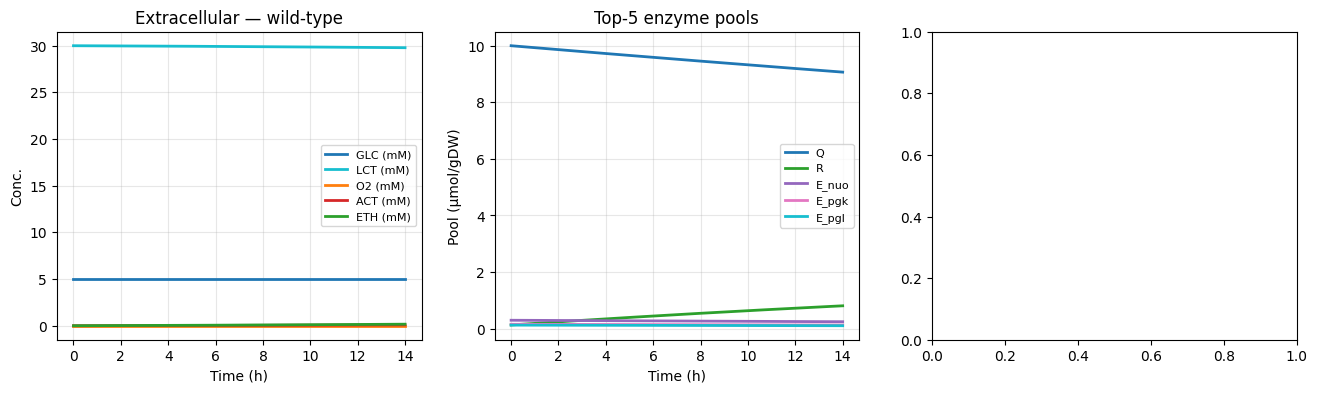

In [16]:
t_b   = sol_base.t
P_b   = sol_base.y[:N_ENZ, :].T
Y_b   = sol_base.y[N_ENZ:, :].T

# Reconstruct flux trajectories at each eval point
V_b = []
for k in range(len(t_b)):
    Vm, _, _ = solve_deFBA_LP(np.clip(P_b[k], 0, None), np.clip(Y_b[k], 0, None))
    V_b.append(Vm if Vm is not None else np.zeros(N_RXN))
V_b = np.array(V_b)

colors_ext = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red', 'tab:green']
fig, axes  = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS, colors_ext)):
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_b, Y_b[:, k], color=col, lw=2, label=f'{name} ({unit})')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Conc.')
ax.set_title('Extracellular — wild-type'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
mean_P = P_b.mean(axis=0)
top5   = np.argsort(mean_P)[-5:][::-1]
cmap5  = plt.cm.tab10(np.linspace(0, 0.9, 5))
for enz_idx, col in zip(top5, cmap5):
    ax.plot(t_b, P_b[:, enz_idx], color=col, lw=2, label=ENZ_NAMES[enz_idx])
ax.set_xlabel('Time (h)'); ax.set_ylabel('Pool (µmol/gDW)')
ax.set_title('Top-5 enzyme pools'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
flux_plot = [('ACK', IDX_ACK, 'tab:orange'),
             ('ETOH', IDX_ETOH, 'tab:red'),
             ('PTS_glc', IDX_PTS, 'tab:blue')]
for name, idx, col in flux_plot:
    ax.plot(t_b, V_b[:, idx], color=col, lw=2, label=name)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Flux (mmol/gDW/h)')
ax.set_title('Key fluxes — wild-type'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Section 5 — Baseline wild-type simulation', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Final: Glc={Y_b[-1,0]:.2f} mM  Lac={Y_b[-1,1]:.2f} mM  '
      f'Ac={Y_b[-1,2]:.2f} mM  EtOH={Y_b[-1,3]:.2f} mM  BM={Y_b[-1,4]:.4f} gDW/L')

---
## Section 6 — Regulated Simulation (Strategy 1b)

At $t_{reg}=6.1$ h, repress ACK (idx 9). Batch ends at $t_f=12.2$ h.

In [ ]:
T_REG     = 6.1
T_END_REG = 12.2
t_eval_reg = np.linspace(0, T_END_REG, 300)


def run_regulated_sim(state0, t_reg, t_end, t_eval=None):
    """Two-phase deFBA: unregulated [0, t_reg) then ACK-repressed [t_reg, t_end]."""
    te1 = t_eval[t_eval <= t_reg] if t_eval is not None else None
    te2 = t_eval[t_eval >= t_reg] if t_eval is not None else None

    sol1, _ = run_deFBA(state0, (0, t_reg), t_eval=te1)
    sol2, _ = run_deFBA(sol1.y[:, -1], (t_reg, t_end), t_eval=te2,
                         regulated_reactions=[IDX_ACK])

    t_cat = np.concatenate([sol1.t,   sol2.t[1:]])
    y_cat = np.concatenate([sol1.y.T, sol2.y.T[1:]], axis=0)
    return t_cat, y_cat


print('Running regulated simulation (Strategy 1b)...')
t0_w = time.time()
t_r, y_r = run_regulated_sim(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
print(f'Done in {time.time()-t0_w:.1f} s')

P_r = y_r[:, :N_ENZ]
Y_r = y_r[:, N_ENZ:]

Running regulated simulation (Strategy 1b)...
Done in 1.0 s


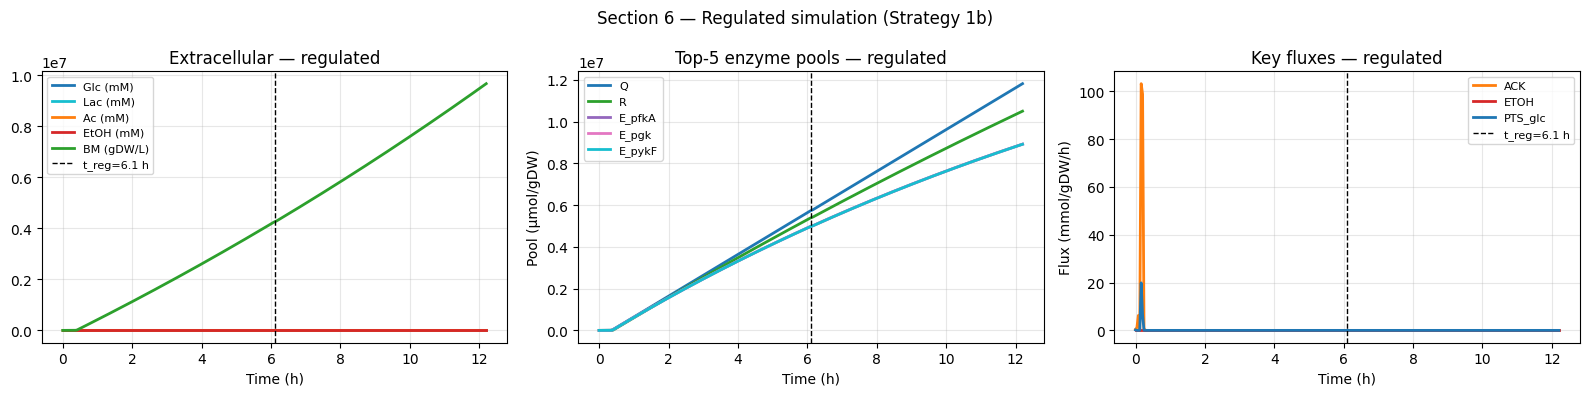

Final EtOH   : 0.00 mM
Productivity : 0.000 mM/h   (target ~4.10 mM/h)


In [ ]:
# Flux reconstruction for regulated simulation
V_r = []
for k in range(len(t_r)):
    reg = [IDX_ACK] if t_r[k] >= T_REG else None
    Vm, _, _ = solve_deFBA_LP(np.clip(P_r[k], 0, None), np.clip(Y_r[k], 0, None),
                                regulated_reactions=reg)
    V_r.append(Vm if Vm is not None else np.zeros(N_RXN))
V_r = np.array(V_r)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS, colors_ext)):
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_r, Y_r[:, k], color=col, lw=2, label=f'{name} ({unit})')
ax.axvline(T_REG, color='k', ls='--', lw=1, label=f't_reg={T_REG} h')
ax.set_xlabel('Time (h)'); ax.set_title('Extracellular — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for enz_idx, col in zip(top5, cmap5):
    ax.plot(t_r, P_r[:, enz_idx], color=col, lw=2, label=ENZ_NAMES[enz_idx])
ax.axvline(T_REG, color='k', ls='--', lw=1)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Pool (µmol/gDW)')
ax.set_title('Top-5 enzyme pools — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
for name, idx, col in flux_plot:
    ax.plot(t_r, V_r[:, idx], color=col, lw=2, label=name)
ax.axvline(T_REG, color='k', ls='--', lw=1, label=f't_reg={T_REG} h')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Flux (mmol/gDW/h)')
ax.set_title('Key fluxes — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Section 6 — Regulated simulation (Strategy 1b)', fontsize=12)
plt.tight_layout(); plt.show()

etoh_final   = Y_r[-1, 3]
productivity = etoh_final / T_END_REG
print(f'Final EtOH   : {etoh_final:.2f} mM')
print(f'Productivity : {productivity:.3f} mM/h   (target ~4.10 mM/h)')

---
## Section 7 — Training Data Generation

50 simulations with perturbed $P_0$ (±20%) and random $t_{reg} \sim U[2, 10]$ h.
Records: $(P, Y, reg\_state) \to V^*$ at every evaluated timestep.

In [ ]:
N_SIM        = 50
PERTURB      = 0.20
T_END_DATA   = 12.0
T_EVAL_DATA  = np.linspace(0, T_END_DATA, 150)
rng          = np.random.default_rng(seed=0)

records = []

for sim_i in range(N_SIM):
    noise   = 1.0 + rng.uniform(-PERTURB, PERTURB, size=N_ENZ)
    P0_i    = np.clip(P0_vec * noise, 0.0, None)
    t_reg_i = rng.uniform(2.0, 10.0)
    s0_i    = np.concatenate([P0_i, Y0])

    for phase_reg, t_span_i, te_i in [
        (None,       (0, t_reg_i),      T_EVAL_DATA[T_EVAL_DATA <= t_reg_i]),
        ([IDX_ACK],  (t_reg_i, T_END_DATA), T_EVAL_DATA[T_EVAL_DATA >= t_reg_i]),
    ]:
        sol_i, _ = run_deFBA(s0_i, t_span_i, t_eval=te_i,
                              regulated_reactions=phase_reg)
        for k in range(len(sol_i.t)):
            P_k = np.clip(sol_i.y[:N_ENZ, k], 0, None)
            Y_k = np.clip(sol_i.y[N_ENZ:, k], 0, None)
            Vm, Vp, st = solve_deFBA_LP(P_k, Y_k, regulated_reactions=phase_reg)
            if Vm is not None:
                records.append({'P': P_k, 'Y': Y_k,
                                 'V_met': Vm, 'V_p': Vp,
                                 'reg': 0 if phase_reg is None else 1})
        # hand off end state to next phase
        s0_i = sol_i.y[:, -1]

    if (sim_i + 1) % 10 == 0:
        print(f'  Sim {sim_i+1:3d}/{N_SIM}  records: {len(records)}')

print(f'\nTotal training samples: {len(records)}')

  Sim  10/50  records: 1500
  Sim  20/50  records: 3000
  Sim  30/50  records: 4500
  Sim  40/50  records: 6000
  Sim  50/50  records: 7500

Total training samples: 7500


Input  X : (7500, 24)
Output V : (7500, 16)


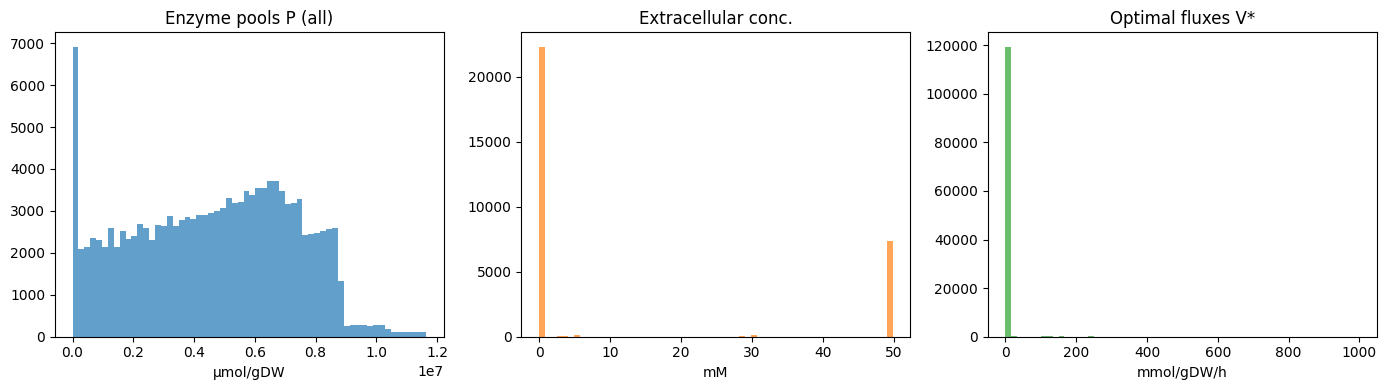

In [ ]:
P_data   = np.stack([r['P']     for r in records])   # (N, N_ENZ)
Y_data   = np.stack([r['Y']     for r in records])   # (N, N_EXT)
V_data   = np.stack([r['V_met'] for r in records])   # (N, N_RXN)
reg_data = np.array([r['reg']   for r in records], dtype=np.float32)  # (N,)

X_input  = np.hstack([P_data, Y_data, reg_data[:, None]])  # (N, N_ENZ+N_EXT+1)
V_output = V_data

print(f'Input  X : {X_input.shape}')
print(f'Output V : {V_output.shape}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(P_data.flatten(), bins=60, color='tab:blue', alpha=0.7)
axes[0].set_title('Enzyme pools P (all)'); axes[0].set_xlabel('µmol/gDW')
axes[1].hist(Y_data[:, :4].flatten(), bins=60, color='tab:orange', alpha=0.7)
axes[1].set_title('Extracellular conc.'); axes[1].set_xlabel('mM')
axes[2].hist(V_output.flatten(), bins=60, color='tab:green', alpha=0.7)
axes[2].set_title('Optimal fluxes V*'); axes[2].set_xlabel('mmol/gDW/h')
plt.tight_layout(); plt.show()

---
## Section 8 — Neural Network Surrogate

Input: $[P,\; Y,\; reg] \in \mathbb{R}^{N_{ENZ}+N_{EXT}+1}$ → Output: $V^* \in \mathbb{R}^{N_{RXN}}$

Architecture: 3 hidden layers × 128 neurons, ReLU.

In [ ]:
class SurrogateDeFBA(nn.Module):
    """Feedforward surrogate: [P, Y, reg] → V*."""
    def __init__(self, n_in, n_out, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(n_in, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


N_IN  = X_input.shape[1]
N_OUT = V_output.shape[1]

X_tr_raw, X_te_raw, V_tr_raw, V_te_raw = train_test_split(
    X_input, V_output, test_size=0.2, random_state=42)

x_scaler = StandardScaler().fit(X_tr_raw)
v_scaler = StandardScaler().fit(V_tr_raw)

X_tr = torch.tensor(x_scaler.transform(X_tr_raw), dtype=torch.float32)
V_tr = torch.tensor(v_scaler.transform(V_tr_raw), dtype=torch.float32)
X_te = torch.tensor(x_scaler.transform(X_te_raw), dtype=torch.float32)
V_te = torch.tensor(v_scaler.transform(V_te_raw), dtype=torch.float32)

print(f'NN input: {N_IN}  output: {N_OUT}')
print(f'Train: {X_tr.shape[0]}  Test: {X_te.shape[0]}')

NN input: 24  output: 16
Train: 6000  Test: 1500


In [ ]:
HIDDEN     = 128
N_LAYERS   = 3
LR         = 1e-3
EPOCHS     = 500
BATCH_SIZE = 256

surrogate  = SurrogateDeFBA(N_IN, N_OUT, HIDDEN, N_LAYERS)
optimiser  = torch.optim.Adam(surrogate.parameters(), lr=LR)
loss_fn    = nn.MSELoss()
train_dl   = DataLoader(TensorDataset(X_tr, V_tr), batch_size=BATCH_SIZE, shuffle=True)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    surrogate.train()
    bl = []
    for xb, vb in train_dl:
        optimiser.zero_grad()
        loss = loss_fn(surrogate(xb), vb)
        loss.backward(); optimiser.step()
        bl.append(loss.item())
    train_losses.append(np.mean(bl))
    surrogate.eval()
    with torch.no_grad():
        val_losses.append(loss_fn(surrogate(X_te), V_te).item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | train {train_losses[-1]:.5f} | val {val_losses[-1]:.5f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(train_losses, label='Train')
ax.semilogy(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_title('Surrogate training curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

KeyboardInterrupt: 

In [ ]:
surrogate.eval()
with torch.no_grad():
    V_pred_sc = surrogate(X_te).numpy()

V_pred_true = v_scaler.inverse_transform(V_pred_sc)
V_test_true = v_scaler.inverse_transform(V_te.numpy())

r2_per_flux = np.array([r2_score(V_test_true[:, j], V_pred_true[:, j])
                         for j in range(N_RXN)])

print(f'Overall R² : {r2_score(V_test_true.flatten(), V_pred_true.flatten()):.4f}')
print('\nPer-flux R²:')
for name, r2 in zip(RXN_NAMES, r2_per_flux):
    bar = '█' * max(0, int(r2 * 20))
    print(f'  {name:10s}: {r2:+.4f}  {bar}')

worst3 = np.argsort(r2_per_flux)[:3]
print(f'\nHardest fluxes: {[RXN_NAMES[j] for j in worst3]}')

---
## Section 9 — Surrogate-Driven Simulation

The NN predicts $V_{met}^*$; enzyme dynamics $\dot{P}$ still use a lightweight LP for $V_p$
(the biosynthesis fluxes are not yet in the surrogate output — a natural extension for later).

In [ ]:
def deFBA_rhs_surrogate(t, state, t_reg_switch=None):
    """
    deFBA ODE RHS using trained NN for V_met and a minimal LP for V_p.

    Parameters
    ----------
    t             : float
    state         : (N_ENZ + N_EXT,)
    t_reg_switch  : float | None  — regulation applied when t >= t_reg_switch
    """
    P = np.clip(state[:N_ENZ], 0.0, None)
    Y = np.clip(state[N_ENZ:], 0.0, None)
    biomass  = Y[4]
    reg_flag = 1.0 if (t_reg_switch is not None and t >= t_reg_switch) else 0.0

    # NN forward pass for V_met
    x_raw    = np.concatenate([P, Y, [reg_flag]]).reshape(1, -1)
    x_tensor = torch.tensor(x_scaler.transform(x_raw), dtype=torch.float32)
    surrogate.eval()
    with torch.no_grad():
        v_sc = surrogate(x_tensor).numpy()
    V_met_pred = v_scaler.inverse_transform(v_sc)[0]

    # Clip irreversible fluxes
    for r in REACTIONS:
        if not r['reversible']:
            V_met_pred[r['idx']] = max(V_met_pred[r['idx']], 0.0)

    # Minimal LP for V_p only (enzyme biosynthesis)
    reg = [IDX_ACK] if reg_flag else None
    _, V_p, _ = solve_deFBA_LP(P, Y, regulated_reactions=reg)
    if V_p is None:
        V_p = np.zeros(N_ENZ)

    V_p_umol = V_p * 1e3
    dP   = V_p_umol - kdeg_vec * P
    dY   = (S_y @ V_met_pred) * biomass
    bTP  = max(b_vec @ P, 1e-12)
    dY[4] = np.dot(b_vec, V_p_umol) / bTP * biomass

    return np.concatenate([dP, dY])


def run_surrogate_regulated(state0, t_reg, t_end, t_eval=None):
    """Two-phase surrogate-driven simulation."""
    te1 = t_eval[t_eval <= t_reg] if t_eval is not None else None
    te2 = t_eval[t_eval >= t_reg] if t_eval is not None else None

    sol1 = solve_ivp(lambda t, s: deFBA_rhs_surrogate(t, s, None),
                     (0, t_reg), state0, t_eval=te1,
                     method='RK45', rtol=1e-4, atol=1e-6, max_step=0.05)
    sol2 = solve_ivp(lambda t, s: deFBA_rhs_surrogate(t, s, t_reg),
                     (t_reg, t_end), sol1.y[:, -1], t_eval=te2,
                     method='RK45', rtol=1e-4, atol=1e-6, max_step=0.05)

    t_cat = np.concatenate([sol1.t,   sol2.t[1:]])
    y_cat = np.concatenate([sol1.y.T, sol2.y.T[1:]], axis=0)
    return t_cat, y_cat


print('Running surrogate-driven simulation...')
t0_s = time.time()
t_sur, y_sur = run_surrogate_regulated(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
t_sur_wall = time.time() - t0_s
print(f'Surrogate done in {t_sur_wall:.2f} s')
Y_sur = y_sur[:, N_ENZ:]

In [ ]:
print('Running exact LP simulation for comparison...')
t0_e = time.time()
t_ex, y_ex = run_regulated_sim(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
t_ex_wall  = time.time() - t0_e
Y_ex = y_ex[:, N_ENZ:]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
rmse_list = []
for k, (name, ax) in enumerate(zip(EXT_METS, axes)):
    t_com  = np.linspace(0, min(t_sur[-1], t_ex[-1]), 200)
    f_sur  = interp1d(t_sur, Y_sur[:, k], fill_value='extrapolate')
    f_ex   = interp1d(t_ex,  Y_ex[:, k],  fill_value='extrapolate')
    rmse   = np.sqrt(np.mean((f_sur(t_com) - f_ex(t_com))**2))
    rmse_list.append(rmse)
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_ex,  Y_ex[:, k],  'k',  lw=2,   label='Exact LP')
    ax.plot(t_sur, Y_sur[:, k], '--', lw=2,   label='Surrogate', color='tab:orange')
    ax.axvline(T_REG, color='grey', ls=':', lw=1)
    ax.set_xlabel('Time (h)'); ax.set_ylabel(f'{name} ({unit})')
    ax.set_title(f'{name}  RMSE={rmse:.3f}'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle('Section 9 — Exact LP vs surrogate', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Wall-clock:  LP={t_ex_wall:.2f} s   Surrogate={t_sur_wall:.2f} s   '
      f'Speedup={t_ex_wall/max(t_sur_wall,1e-3):.1f}×')
print('RMSE per variable:')
for name, rmse in zip(EXT_METS, rmse_list):
    print(f'  {name:8s}: {rmse:.4f}')

---
## Section 10 — Bilevel Optimisation

Outer Nelder-Mead loop over $(t_f, t_{reg})$ minimising $-\text{EtOH}(t_f)/t_f$
using the surrogate-driven ODE as the inner model.

In [ ]:
OBJ_N = {'n': 0}

def objective(params):
    """
    Negative ethanol productivity for Nelder-Mead minimisation.

    Parameters
    ----------
    params : [tf (h), treg (h)]

    Returns
    -------
    float  -EtOH(tf) / tf
    """
    tf, treg = float(params[0]), float(params[1])
    if tf < 4.0 or tf > 22.0 or treg < 0.5 or treg >= tf:
        return 0.0   # infeasible penalty
    try:
        t_i, y_i = run_surrogate_regulated(
            state0, treg, tf, t_eval=np.linspace(0, tf, 100))
        etoh = max(y_i[-1, N_ENZ + 3], 0.0)
    except Exception:
        return 0.0
    OBJ_N['n'] += 1
    if OBJ_N['n'] % 10 == 0:
        print(f'  iter {OBJ_N["n"]:3d} | tf={tf:.2f} treg={treg:.2f} '
              f'| EtOH={etoh:.2f} prod={etoh/tf:.3f} mM/h')
    return -(etoh / tf)


print('Starting Nelder-Mead optimisation over (tf, treg)...')
res_opt = minimize(objective, x0=[12.0, 6.0], method='Nelder-Mead',
                   options={'xatol': 0.1, 'fatol': 0.01, 'maxiter': 200})

tf_opt, treg_opt = res_opt.x
prod_opt = -res_opt.fun
print(f'\nOptimised:')
print(f'  tf*   = {tf_opt:.2f} h   (reference: 12.2 h)')
print(f'  treg* = {treg_opt:.2f} h  (reference: 6.1 h)')
print(f'  prod* = {prod_opt:.3f} mM/h  (reference: ~4.10 mM/h)')

In [ ]:
t_opt_ev  = np.linspace(0, tf_opt, 200)
t_opt, y_opt = run_surrogate_regulated(state0, treg_opt, tf_opt, t_eval=t_opt_ev)
Y_opt = y_opt[:, N_ENZ:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS[:4],
        ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red'])):
    ax.plot(t_opt, Y_opt[:, k], color=col, lw=2, label=name)
ax.axvline(treg_opt, color='k', ls='--', lw=1, label=f't_reg={treg_opt:.2f} h')
ax.set_xlabel('Time (h)'); ax.set_title(f'Optimised (tf={tf_opt:.2f} h)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_opt, Y_opt[:, 4], color='tab:green', lw=2)
ax.axvline(treg_opt, color='k', ls='--', lw=1)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Biomass (gDW/L)')
ax.set_title('Biomass — optimised'); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(t_ex,  Y_ex[:, 3],  'k',          lw=2, label='Ref (t_reg=6.1, tf=12.2)')
ax.plot(t_opt, Y_opt[:, 3], 'tab:red', ls='--', lw=2,
        label=f'Opt (t_reg={treg_opt:.1f}, tf={tf_opt:.1f})')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Ethanol (mM)')
ax.set_title('Ethanol: reference vs optimised')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(f'Section 10 — Bilevel optimisation   prod* = {prod_opt:.3f} mM/h', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Reference  : tf=12.2 h  t_reg=6.1 h  prod=~4.10 mM/h')
print(f'Optimised  : tf={tf_opt:.2f} h  t_reg={treg_opt:.2f} h  prod={prod_opt:.3f} mM/h')